# 5004 Homework2 (Coding Part)

Author: LAN, Tianwei <br>
Email: tlanaa@connect.ust.hk

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIG_DIGITS = 4
pd.set_option("display.float_format", lambda x: f"{x:.{SIG_DIGITS}g}")

def fmt_sig(x, sig=SIG_DIGITS):
    return f"{float(x):.{sig}g}"

def fmt_vec(v, sig=SIG_DIGITS):
    arr = np.asarray(v, dtype=float)
    return "(" + ", ".join(f"{val:.{sig}g}" for val in arr) + ")"

## Q1

In [13]:
A1 = np.array([[8, -3, 2], [4, 11, -1], [6, 3, 12]], dtype=float)
b1 = np.array([20, 33, 36], dtype=float)
x0 = np.zeros(3)

def jacobi_steps(A, b, x_init, num_steps=2):
    D = np.diag(np.diag(A))
    R = A - D
    x = x_init.astype(float).copy()
    out = []
    for k in range(1, num_steps + 1):
        x = (b - R @ x) / np.diag(A)
        out.append((k, x.copy()))
    return out

def gs_steps(A, b, x_init, num_steps=2):
    L = np.tril(A)
    U = A - L
    x = x_init.astype(float).copy()
    out = []
    for k in range(1, num_steps + 1):
        x = np.linalg.solve(L, b - U @ x)
        out.append((k, x.copy()))
    return out

jac = jacobi_steps(A1, b1, x0, num_steps=2)
gs = gs_steps(A1, b1, x0, num_steps=2)

rows = []
for k, x in jac:
    rows.append(["Jacobi", k, x[0], x[1], x[2]])
for k, x in gs:
    rows.append(["Gauss-Seidel", k, x[0], x[1], x[2]])

df_q1 = pd.DataFrame(rows, columns=["Method", "Iteration", "x1", "x2", "x3"])
df_q1_display = df_q1.copy()
for col in ["x1", "x2", "x3"]:
    df_q1_display[col] = df_q1_display[col].map(fmt_sig)
df_q1_display

,Method,Iteration,x1,x2,x3
0,Jacobi,1,2.5,3,3
1,Jacobi,2,2.875,2.364,1
2,Gauss-Seidel,1,2.5,2.091,1.227
3,Gauss-Seidel,2,2.977,2.029,1.004


From the computed table (4 significant digits):
- Jacobi: $x^{(1)}=(2.500,3.000,3.000)$, $x^{(2)}=(2.875,2.364,1.000)$
- Gauss-Seidel: $x^{(1)}=(2.500,2.091,1.227)$, $x^{(2)}=(2.977,2.029,1.004)$

## Q2

In [18]:
A2 = np.array([
    [4, 1, 1, 1],
    [1, 4, 1, 1],
    [1, 1, 4, 1],
    [1, 1, 1, 4]
], dtype=float)
b2 = np.ones(4)
x0_2 = np.zeros(4)
tol = 1e-5

def jacobi_solver(A, b, x_init, tol=1e-5, max_iter=100000):
    x = x_init.astype(float).copy()
    D = np.diag(np.diag(A))
    R = A - D
    for k in range(1, max_iter + 1):
        x_new = (b - R @ x) / np.diag(A)
        if np.linalg.norm(x_new - x, ord=np.inf) <= tol:
            return x_new, k
        x = x_new
    raise RuntimeError("Jacobi did not converge within max_iter.")

def sor_solver(A, b, x_init, omega=1.3, tol=1e-5, max_iter=100000):
    x = x_init.astype(float).copy()
    n = len(x)
    for k in range(1, max_iter + 1):
        x_old = x.copy()
        for i in range(n):
            sigma1 = A[i, :i] @ x[:i]
            sigma2 = A[i, i+1:] @ x_old[i+1:]
            gs_value = (b[i] - sigma1 - sigma2) / A[i, i]
            x[i] = (1 - omega) * x_old[i] + omega * gs_value
        if np.linalg.norm(x - x_old, ord=np.inf) <= tol:
            return x, k
    raise RuntimeError("SOR did not converge within max_iter.")

x_jacobi, it_jacobi = jacobi_solver(A2, b2, x0_2, tol=tol)
x_sor, it_sor = sor_solver(A2, b2, x0_2, omega=1.3, tol=tol)
x_exact = np.full(4, 1 / 7)

result_q2 = pd.DataFrame({
    "Method": ["Jacobi", "SOR (omega=1.3)"],
    "Iterations": [it_jacobi, it_sor],
    "Approx x": [fmt_vec(x_jacobi), fmt_vec(x_sor)],
    "Inf-norm error vs exact": [
        fmt_sig(np.linalg.norm(x_jacobi - x_exact, ord=np.inf)),
        fmt_sig(np.linalg.norm(x_sor - x_exact, ord=np.inf))
    ]
})
result_q2

,Method,Iterations,Approx x,Inf-norm error vs exact
0,Jacobi,37,"(0.1429, 0.1429, 0.1429, 0.1429)",3.405e-06
1,SOR (omega=1.3),13,"(0.1429, 0.1429, 0.1429, 0.1429)",1.559e-06


Both methods converge to approximately $(1/7,1/7,1/7,1/7)$.
Jacobi uses 37 iterations, while SOR ($\omega=1.3$) uses 13 iterations.
Their infinity-norm errors vs exact are about $3.4 \times 10^{-6}$ (Jacobi) and $1.6  \times 10^{-6}$ (SOR), both shown with 4 significant digits.

## Q3

In [27]:
f = lambda x: np.exp(x) / x
fprime_exact = np.exp(2) * (2 - 1) / 4  # exact derivative of e^x/x at x=2

hs = 2.0 ** (-np.arange(1, 11))
approx = (f(2 + hs) - f(2 - hs)) / (2 * hs)
err = np.abs(approx - fprime_exact)
order = np.empty_like(err)
order[:] = np.nan
order[1:] = np.log2(err[:-1] / err[1:])

table_q3 = pd.DataFrame({
    "h": hs,
    "central_difference": approx,
    "abs_error": err,
    "estimated_order": order
})
table_q3_display = table_q3.copy()
for col in ["h", "central_difference", "abs_error", "estimated_order"]:
    table_q3_display[col] = table_q3_display[col].map(lambda v: "nan" if pd.isna(v) else fmt_sig(v))
table_q3_display

,h,central_difference,abs_error,estimated_order
0,0.5,1.885,0.03794,nan
1,0.25,1.857,0.00959,1.984
2,0.125,1.85,0.002403,1.996
3,0.0625,1.848,0.0006012,1.999
4,0.03125,1.847,0.0001503,2
5,0.01562,1.847,3.758e-05,2
6,0.007812,1.847,9.396e-06,2
7,0.003906,1.847,2.349e-06,2
8,0.001953,1.847,5.872e-07,2
9,0.0009766,1.847,1.468e-07,2


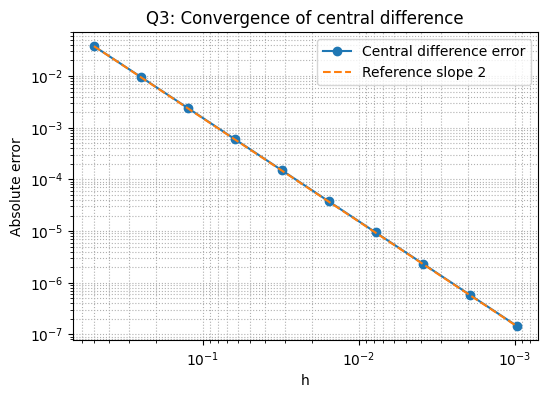

Exact f'(2) = 1.847
Last estimated order = 2


In [28]:
plt.figure(figsize=(6, 4))
plt.loglog(hs, err, 'o-', label='Central difference error')
plt.loglog(hs, err[0] * (hs / hs[0])**2, '--', label='Reference slope 2')
plt.gca().invert_xaxis()
plt.xlabel('h')
plt.ylabel('Absolute error')
plt.title('Q3: Convergence of central difference')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

print(f"Exact f'(2) = {fmt_sig(fprime_exact)}")
print(f"Last estimated order = {fmt_sig(order[-1])}")

The estimated order approaches $2.000$, which confirms second-order convergence of the central difference scheme.
Using 4 significant digits: exact $f'(2)=1.847$ and final observed order is $2.000$.

## Q4

In [32]:
def ode_f(t, y):
    return 2 / t**2 * (t * y - 2 * y**2)

def y_exact(t):
    return t**2 / (4 * t - 6)

h = 1 / 128
t = np.arange(2, 4 + h / 2, h)

# Forward Euler
y_fe = np.zeros_like(t)
y_fe[0] = 2.0
for n in range(len(t) - 1):
    y_fe[n + 1] = y_fe[n] + h * ode_f(t[n], y_fe[n])

# Backward Euler: solve a quadratic at each time step
y_be = np.zeros_like(t)
y_be[0] = 2.0
for n in range(len(t) - 1):
    tp = t[n + 1]
    a = 4 * h / tp**2
    b = 1 - 2 * h / tp
    c = -y_be[n]
    disc = b**2 - 4 * a * c
    r1 = (-b + np.sqrt(disc)) / (2 * a)
    r2 = (-b - np.sqrt(disc)) / (2 * a)
    y_be[n + 1] = r1 if abs(r1 - y_be[n]) < abs(r2 - y_be[n]) else r2

y_ex = y_exact(t)

summary_q4 = pd.DataFrame({
    "Method": ["Forward Euler", "Backward Euler"],
    "y(4) approx": [fmt_sig(y_fe[-1]), fmt_sig(y_be[-1])],
    "abs error at t=4": [fmt_sig(abs(y_fe[-1] - y_exact(4))), fmt_sig(abs(y_be[-1] - y_exact(4)))]
})
summary_q4

,Method,y(4) approx,abs error at t=4
0,Forward Euler,1.597,0.002717
1,Backward Euler,1.603,0.002696


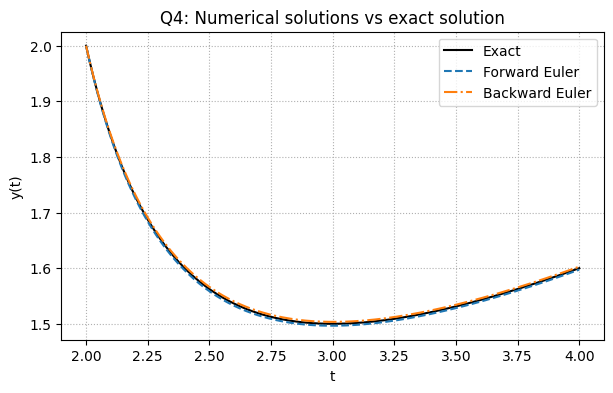

In [33]:
plt.figure(figsize=(7, 4))
plt.plot(t, y_ex, 'k-', label='Exact')
plt.plot(t, y_fe, '--', label='Forward Euler')
plt.plot(t, y_be, '-.', label='Backward Euler')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Q4: Numerical solutions vs exact solution')
plt.legend()
plt.grid(True, ls=':')
plt.show()

With $h=1/128$, both Euler methods give close approximations at $t=4$.
Using 4 significant digits: exact $y(4)=1.600$, Forward Euler $y(4)=1.597$ (error $2.7 \times10^{-3}$), and Backward Euler $y(4)=1.603$ (error $2.7 \times10^{-3}$).